<div style="background-color:yellow; text-align:center; vertical-align: middle; padding:40px 0;">
<a style="font-size: 30px;" >
    <font color=red>COGS-514 : Cognition and Machine Learning</font>
</a>
    <br>
    <br>
<a style="font-size: 25px;" >
    <font color=red>Course Project - Part 3</font>
</a>
    <br>
    <br>
<a style="font-size: 20px;" >
    <font color=red>Turgay Yıldız , Cognitive Sciences, Middle East Technical University (METU)</font>
</a>
</div>


###### <font color=red > Note : This notebook was written in the dark theme. Some parts of the texts may not seem correctly in the light theme. </font>

## <div span style="background-color:green;"> <font color=black> $$ \text {Part - 3 : Siamese Networks : 20-Way One-Shot Classification on Omniglot Dataset } $$ </font> </div>


A <font color=blue> Siamese neural network </font>, also known as a <font color=blue> twin neural network </font>, employs **identical weights** to consecutively process two distinct input vectors/images, generating corresponding output vectors for <font color=red>comparison</font>. Frequently, one output vector is precomputed, establishing a reference point for evaluating the other output vector for comparision. Actually, the dimensions of inputs and outputs can be changed according to the aim of the model. What makes a network Siamese is its unique architecture. Siamese networks use same network for two different inputs. Then, they compare outputs of these two inputs. In our case, it will take 2 images in a row and will give 2 vectors. 

Similarity measures find application in scenarios where twin networks are utilized, such as recognizing handwritten checks, automatically detecting faces in camera images, and matching queries with indexed documents. One of the most renowned applications of twin networks is in face recognition, where precomputed images of individuals are compared with images captured by turnstiles or similar devices.[^1]

[^1]: https://en.wikipedia.org/wiki/Siamese_neural_network

### <div span style="background-color:green;"> <font color=black> $$ \text { How to Train a Siamese Network }$$ </font> </div>


1. Begin by initializing the Siamese network along with the chosen loss function and optimizer.
2. Feed the first image of the pair through the network.
3. Proceed by passing the second image of the pair through the network.
4.  Calculate the loss by comparing the outputs (vectors) generated from the first and second images.
5.  Utilize backpropagation to compute the gradients of the model based on the calculated loss.
6.  Update the weights of the network using the optimizer.
7.  Save the trained model for future use.[^1]

[^1]: https://builtin.com/machine-learning/siamese-network 

### <div span style="background-color:green;"> <font color=black> $$ \text {Advantages and Disadvantages of Siamese Networks }$$ </font> </div>

### <font color=blue> Advantages of Siamese Networks: </font>

<font color=red> Enhanced Robustness to Class Imbalance : </font>A minimal set of images per class is adequate for Siamese networks to effectively recognize those images in subsequent tasks.

<font color=red>Compatible with Other Classifiers :</font> As the learning mechanism of Siamese neural networks (SNN) differs somewhat from conventional classification models, integrating it with a classifier often yields superior results compared to combining two correlated supervised models (such as GBM and RF classifiers). In this project, however, I encountered with the opposite of this circumstance. First, this was mostly because I could not manage to handle with loss functions. I even wrote custom loss functions. However, because of the immense time that it requires to train, I could not get the best results. Second, there were some novel and more complex loss functions, I did not start to work with them. 

<font color=red>Semantic Similarity Learning : </font>SNN prioritizes learning embeddings in deeper layers that cluster similar classes or concepts closely together, thereby enabling the acquisition of semantic similarity. 

### <font color=blue>  Disadvantages of Siamese Networks:  </font> 

<font color=red>Increased Training Time Compared to Standard Networks : </font>Due to the requirement of learning from quadratic pairs Siamese networks operate slower than conventional pointwise learning approaches. In this project, I experienced that the time required for one epoch was between 15 and 20 minutes depending on the number of parameters and batches. Since I changed the model and hyper-parameters many times, it took many days just for training the model. 

<font color=red>Absence of Probabilistic Outputs : </font>As training involves pairwise learning, Siamese networks do not yield probabilities for predictions but instead provide distances from each class. However, this problem can be solved by some additional codes. In this project I also tried this. Since there are thousands of ways to build a model, it is an art to build the best ones. It, therefore, takes time to be an expert. [^1]

[^1]: https://builtin.com/machine-learning/siamese-network

### <div span style="background-color:gray;"> <font color=black> $$ \text { Dataset :  Omniglot}$$ </font> </div>

The Omniglot dataset consists of 1,623 distinct handwritten characters from 50 different alphabets. Each character is represented by 20 unique images, along with stroke data provided as x and y coordinates in text files. These characters were independently drawn by 20 individuals through Amazon's Mechanical Turk platform. Each image is paired with stroke data, presenting sequences of [x, y, t] coordinates where time (t) is measured in milliseconds.

The dataset is divided into two parts: pre-train and one-shot. The pre-train part comprises 30 alphabets, while the one-shot part includes the remaining 20 alphabets. Initially, the models were pre-trained using the 30 alphabets. Subsequently, the models were trained using only one image from each character (class) of the remaining 20 alphabets. It is crucial that the models are not exposed to other images from these characters from one-shot data to ensure the integrity of the one-shot classification process.


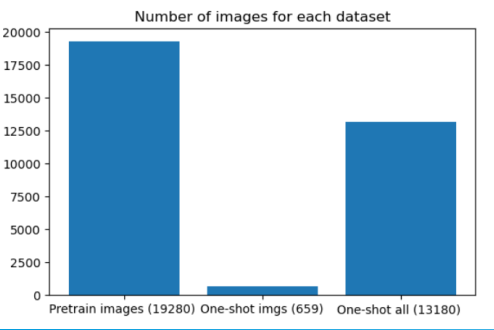

I aggregated pre-train images and I get **90.300** images to pre-train the models. I did not touch the One-Shot data. 

### <div span style="background-color:gray;"> <font color=black> $$ \text { Two Different Models, Two Different Siamese Networks: }$$ </font> </div>

1. Res-NET 18
2. CNN from scratch 

### <div span style="background-color:yellow;"> <font color=red> $$ \text { Res-NET 18}$$ </font> </div>

In [ ]:
class SiameseNetwork_1_(nn.Module):
    def __init__(self): 
        super(SiameseNetwork_1_, self).__init__()


        self.backbone = models.resnet18(weights=None)                  

        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        self.fc_in_features = self.backbone.fc.in_features

        # remove the last layer of resnet18 (linear layer which is before avgpool layer) 
        self.backbone = torch.nn.Sequential(*(list(self.backbone.children())[:-1])) 

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.BatchNorm1d(256), 
            nn.ReLU(inplace=True),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32), 
            nn.ReLU(inplace=True),

            nn.Linear(32, 1),

        )

        # initialize the weights
        self.backbone.apply(self.init_weights)
        self.fc.apply(self.init_weights)
        
    def init_weights(self, m):
        
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01) 


    def forward_once(self, x):

        x = self.backbone(x)
        x = x.view(x.size()[0], -1) 

        return x 
        

    def forward(self, input1, input2):
        
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)
        
        return output

### <div span style="background-color:yellow;"> <font color=red> $$ \text { Other Model : CNN }$$ </font> </div>


Note : I created this model from scratch to employ it as a basemodel (the Second Network) for the Second Siamese.

In [ ]:
class N_way_one_shot_siamese(nn.Module):
    
    def __init__(self, dropout_prob = 0.0):
        
        super(N_way_one_shot_siamese, self).__init__()
        

        self.e11   = nn.Conv2d(1, 32, kernel_size=7, padding=3)                                          # 105 x 105 
        self.bn11  = nn.BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)  # 105 x 105 
        self.activation11 = nn.ReLU() 
        
        self.e12   = nn.Conv2d(32, 32, kernel_size=5, padding=2)    
        self.bn12  = nn.BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation12 = nn.ReLU()  

        self.pool1    = nn.MaxPool2d(kernel_size=2, stride=2)       #  52   x   52     
        self.dropout1 = nn.Dropout2d(p=dropout_prob)
 
        self.e13   = nn.Conv2d(32, 64, kernel_size=5, padding=2)     
        self.bn13  = nn.BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation13 = nn.ReLU() 
        
        self.e14   = nn.Conv2d(64, 64, kernel_size=5, padding=2)    
        self.bn14  = nn.BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation14 = nn.ReLU() 

        self.pool2    = nn.MaxPool2d(kernel_size=2, stride=2)       #   26   x  26   
        self.dropout2 = nn.Dropout2d(p=dropout_prob)

        self.e15   = nn.Conv2d(64, 128, kernel_size=5, padding=2)    
        self.bn15  = nn.BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation15 = nn.ReLU()

        self.e16   = nn.Conv2d(128, 128, kernel_size=5, padding=2)    
        self.bn16  = nn.BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation16 = nn.ReLU()

        self.pool3    = nn.MaxPool2d(kernel_size=2, stride=2)       #   13   x   13    
        self.dropout3 = nn.Dropout2d(p=dropout_prob)

        self.e17   = nn.Conv2d(128, 256, kernel_size=5, padding=2)    
        self.bn17  = nn.BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation17 = nn.ReLU()

        self.e18   = nn.Conv2d(256, 256, kernel_size=5, padding=2)    
        self.bn18  = nn.BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation18 = nn.ReLU()

        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)     #  6    x    6  pixels     

        self.e19   = nn.Conv2d(256, 512, kernel_size=5, padding=2)    
        self.bn19  = nn.BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation19 = nn.ReLU()

        self.e20   = nn.Conv2d(512, 512, kernel_size=5, padding=2)    
        self.bn20  = nn.BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation20 = nn.ReLU()

        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)     #  3    x    3  pixels 
         



        # *************************** Fully Connected Layers **************************
        
        
        self.fc1    = nn.Linear(4608, 1024)         

       

    def forward(self, x): 
        
    
        xe11 = self.activation11(self.bn11(self.e11(x)))      
        xe12 = self.activation12(self.bn12(self.e12(xe11)))
        xp1  = self.dropout1(self.pool1(xe12))
        
        xe13 = self.activation13(self.bn13(self.e13(xp1)))
        xe14 = self.activation14(self.bn14(self.e14(xe13)))
        xp2  = self.dropout2(self.pool2(xe14))

        xe15 = self.activation15(self.bn15(self.e15(xp2)))      
        xe16 = self.activation16(self.bn16(self.e16(xe15))) 
        xp3  = self.dropout3(self.pool3(xe16))
        
        xe17 = self.activation17(self.bn17(self.e17(xp3)))
        xe18 = self.activation18(self.bn18(self.e18(xe17))) 
        xp4  = self.pool4(xe18) 

        xe19 = self.activation19(self.bn19(self.e19(xp4)))
        xe20 = self.activation20(self.bn20(self.e20(xe19))) 
         
        xp5  = self.pool5(xe20) 

        xfc0 = xp5.view(xp5.size(0), -1)    
        
        out           =   self.fc1(xfc0)          
         
        return out


In [ ]:
class SiameseNetwork_2_(nn.Module):
    def __init__(self): 
        super(SiameseNetwork_2_, self).__init__()


        self.backbone = N_way_one_shot_siamese()                  


        self.fc = nn.Sequential(
                                nn.Linear(1024 * 2, 512),
                                nn.BatchNorm1d(512), 
                                nn.ReLU(inplace=True),

                                nn.Linear(512, 128),
                                nn.BatchNorm1d(128), 
                                nn.ReLU(inplace=True),

                                nn.Linear(128, 32),
                                nn.BatchNorm1d(32), 
                                nn.ReLU(inplace=True),
            
                                nn.Linear(32, 1),  
                  
                            )


    def initialize_weights(self):

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)  
 


    def forward_once(self, x):

        x = self.backbone(x)
        x = x.view(x.size()[0], -1) 

        return x 
        

    def forward(self, input1, input2):
        
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        output  = torch.cat((output1, output2), 1)

        output  = self.fc(output)
        
        return output  

### <div span style="background-color:gray;"> <font color=black> $$ \text { Import Res-NET }$$ </font> </div>


I did not take all the codes here, since there are many custom functions in the ipynb files. Therefore, I did take only architecture parts of the models and I am just importing them to make 20-Way One-Shot Classification. By importing the ipynb files, I can employ all the custom functions without taking them here. If I would take all the codes here, it would be very hard to explain everything, since there are many custom functions. 

In [2]:
%run resnet_18_siamese.ipynb

### <div span style="background-color:gray;"> <font color=black> $$ \text { Step Learning Rate Scheduler : }$$ </font> </div>


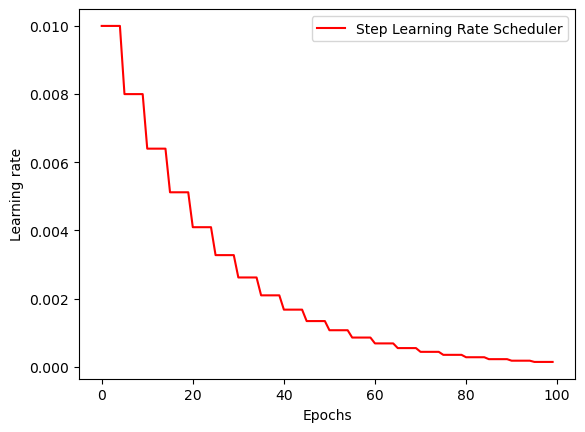

In [3]:
ls = lr_scheduler_plot(0.01, 5, 0.8, 100)

### <div span style="background-color:gray;"> <font color=black> $$ \text { Optimizer Choice :  }$$ </font> </div>


I stick to the <font color=red> Adam optimizer </font> in both models. It works well.

### <div span style="background-color:gray;"> <font color=black> $$ \text { Plot Validation and Training Losses :  }$$ </font> </div>


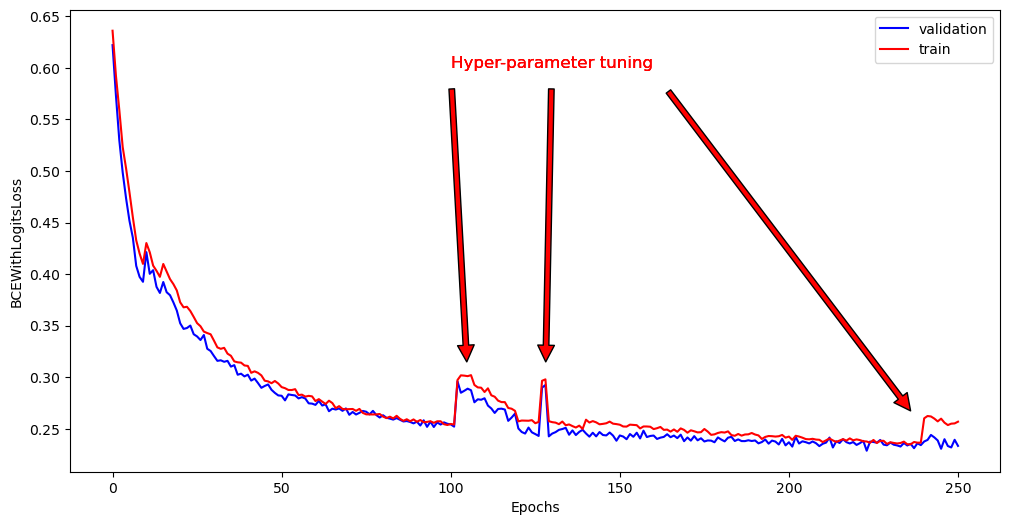

In [14]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

ax.plot(val_loss, "b-", label="validation")
ax.plot(train_loss, "r-", label="train")

plt.annotate('Hyper-parameter tuning', xy=(105, 0.30), xytext=(100, 0.60),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='r')

plt.annotate('Hyper-parameter tuning', xy=(128, 0.30), xytext=(100, 0.60),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='r')

plt.annotate('Hyper-parameter tuning', xy=(240, 0.25), xytext=(100, 0.60),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='r')

ax.set_xlabel("Epochs")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()

<br>

As you can see from the plot above, I did hyper-parameter tuning many times. I changed learning rate, scheduler, even architecture itself. However, since Siamese Networks take too much time, each time I changed the architecture, I had to start the training from scratch. This is mainly because of the fact that when model changes, weights also change; therefore, you can not use the weights of the old model. Hence, these models take many days to train. 

<br>

### <div span style="background-color:gray;"> <font color=black> $$ \text { Create Indices for 20-Way One-Shot Classification :  }$$ </font> </div>


In [15]:
i_x,  i_y   =  indices(1, 13180, 20)  

### <div span style="background-color:gray;"> <font color=black> $$ \text { Plot the Data by Employing Indices :  }$$ </font> </div>


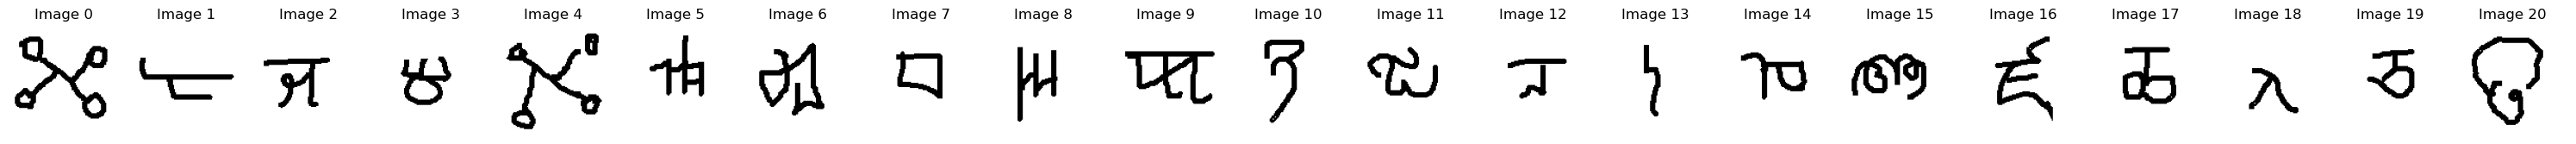

In [20]:
plot_img(one_shot[i_x[0]], 1, 21, 30, 30 )

In [22]:
np.argmax(i_y[0]) +  1

4

### <div span style="background-color:gray;"> <font color=black> $$ \text { 20-Way One-Shot Classification on One-Shot Data :  }$$ </font> </div>


In [23]:
dataset = MyDataset_test(one_shot, i_x, i_y,  transform=transform) 

In [24]:
len(dataset)

13180

In [ ]:
preds , targets = get_preds_and_targets(dataset, model,  "twenty_way")

In [26]:
test(preds, targets, "twenty_way")    

----------------------------------------------------------------------------------------
Number of correct predictions: 9915
Number of wrong  predictions : 3265
Number of accuracy rate      : 0.7522761760242792
Number of error rate         : 0.2477238239757208
----------------------------------------------------------------------------------------


### <div span style="background-color:gray;"> <font color=black> $$ \text { Import CNN :  }$$ </font> </div>


In [64]:
%run 20_way_one_shot_siamese.ipynb

### <div span style="background-color:gray;"> <font color=black> $$ \text { Plot Validation and Training Losses :  }$$ </font> </div>


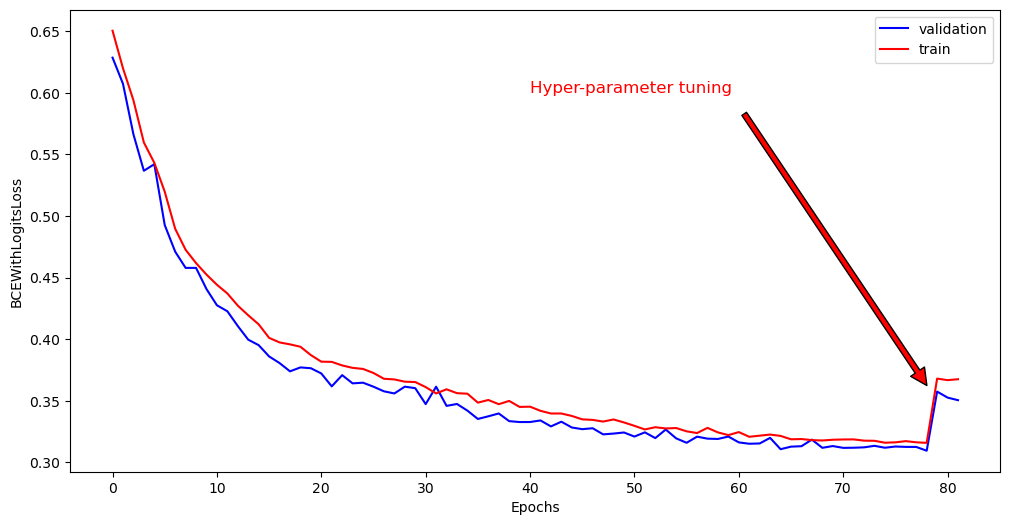

In [50]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

ax.plot(val_loss, "b-", label="validation")
ax.plot(train_loss, "r-", label="train")


plt.annotate('Hyper-parameter tuning', xy=(79, 0.35), xytext=(40, 0.60),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='r')

ax.set_xlabel("Epochs")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()

<br>

As you can see from the plot above, I just did one hyper-parameter tuning because before training this model, I created many models and trained them and tuned hyper-parameters of them. However, their prediction accuracies were not good. Hence, I picked this model and trained it, because it was learning faster than the other models. 

At the end of the model, even if I used a learning rate scheduler, I decided to decrease the learning rate (to 0.0001) and force it to learn more. However, as you can see from the plot, it did not learn any more. 

<br>

### <div span style="background-color:gray;"> <font color=black> $$ \text { 20-Way One-Shot Classification on One-Shot Data :  }$$ </font> </div>


In [56]:
dataset2 = MyDataset_test(one_shot, i_x, i_y,  transform=transform) 

In [57]:
preds2 , targets2 = get_preds_and_targets(dataset2, model2,  "twenty_way")

In [53]:
test(preds, targets, "twenty_way") 

----------------------------------------------------------------------------------------
Number of correct predictions: 9915
Number of wrong  predictions : 3265
Number of accuracy rate      : 0.7522761760242792
Number of error rate         : 0.2477238239757208
----------------------------------------------------------------------------------------


### <div span style="background-color:gray;"> <font color=black> $$ \text { Literature Review :  }$$ </font> </div>


I took all the best models in the literature which are belong to the research on topics such as <font color=red>Human level concept learning </font> , and <font color=blue>Building machines that learn and think like people </font>. 

DOI:  https://doi.org/10.1017/S0140525X16001837

DOI:  https://doi.org/10.1126/science.aab3050


As you can see from the picture below, there are very low accuracy rates on the right hand-side. However, at left hand-side (text part), there are best results. I am going to compare my models' results with those results. 

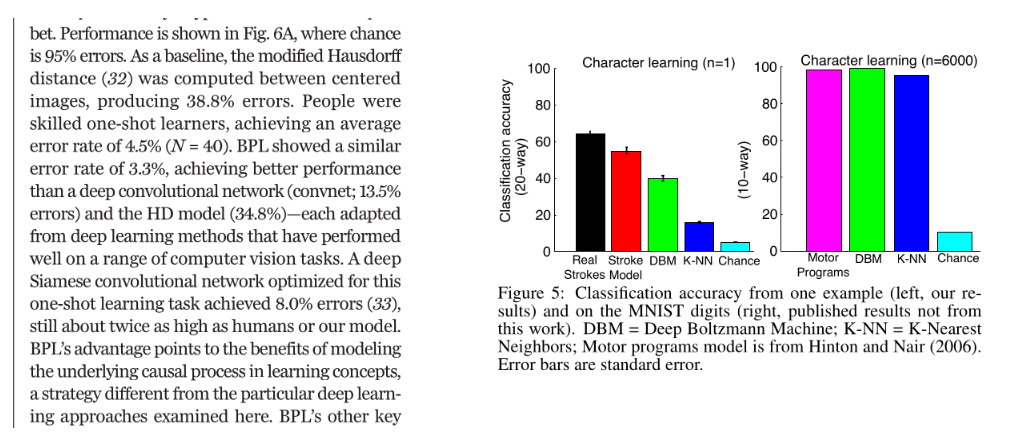

<br>

Additionally, I also created a CNN model (you can see it as "My best model" in the plots below) to compare the result of it with Siamese Networks' results and with models in the literature. Moreover, there is also a baseline model in the literature which I also took. 

What's more, I used ResNET 18 and ResNET 50 , I freezed the first 6 blocks of them and I trained for remaining 4 blocks to make 20-Way One-Shot Classification without Siamese architecture. I will add these results as well. 

<br>

### <div span style="background-color:gray;"> <font color=black> $$ \text { My Best Model :  }$$ </font> </div>


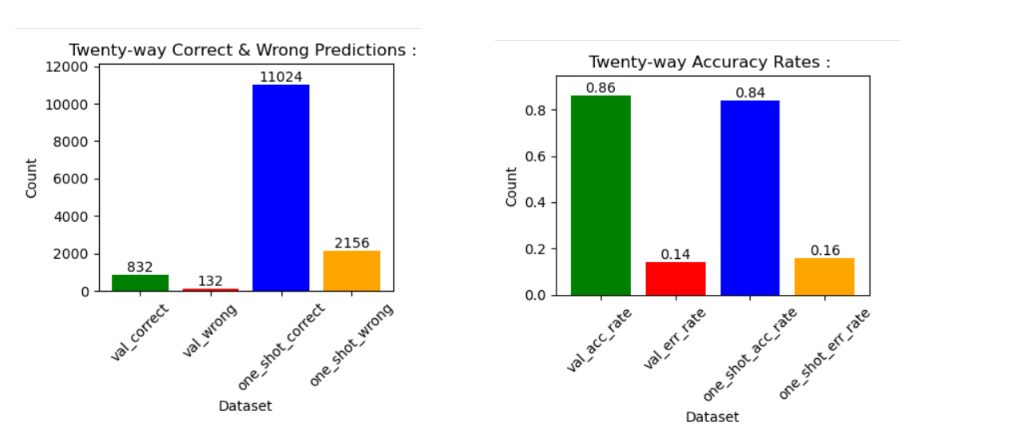

## <div span style="background-color:gray;"> <font color=black> $$ \text { Results:  }$$ </font> </div>


I put the results in an order : from best to the worst, according to their error rates.

In [59]:
compare_MIT_literature = {
    
                        "BPL": 3.3, "People ": 4.5 ,"Deep Siamese": 8, "Deep CNN": 13.5,
                        "My Best Model (CNN): ": 16.3, "ResNET-50 (not siamese)": 18.2, "ResNET-18 (not-siamese)" : 19.6, 
                        "ResNET-18 Siamese" : 24.7, "CNN-Siamese" : 24.7 , 
                        "HD Model": 34.8 , "Baseline ": 38.8

                    } 


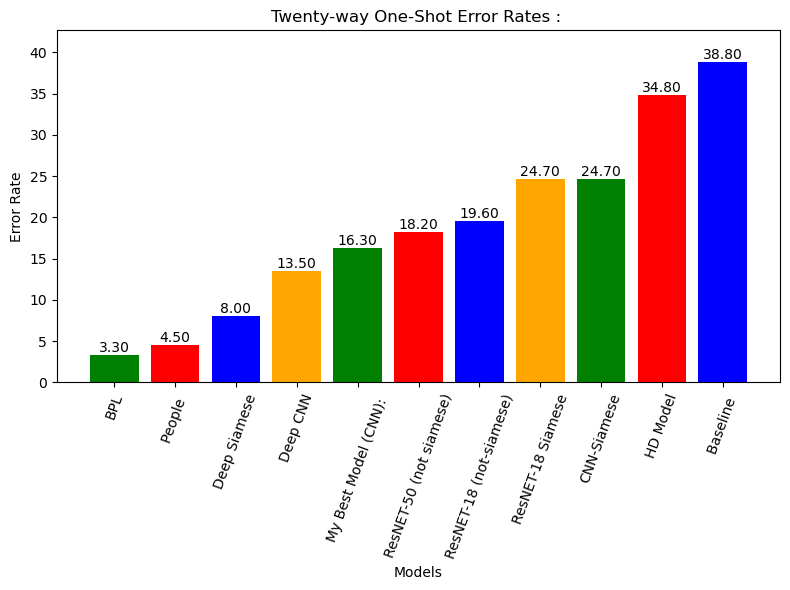

In [65]:
plot_results(compare_MIT_literature)

### <div span style="background-color:green;"> <font color=black> $$ \text { Comments on Results : }$$ </font> </div>


During my research, I trained several models with varying architectures, including <font color=red>Siamese-like networks</font>. I developed multiple custom loss functions for two primary reasons. Firstly, I aimed to reduce the **training time**, as these models typically require significant computational resources. Secondly, I sought to achieve a lower error rate compared to existing results in the literature, particularly those obtained using the **Deep Siamese network**, as depicted in the plot above.


I trained five models, ranging from "**My best model**" to "**CNN (siamese)**," as illustrated in the aforementioned plot. I have included only the Siamese network codes here, as this section of the project focuses on understanding and explaining the **Siamese architecture**. Including all models would have resulted in a chaotic notebook.

All the models I created, both from scratch and using pre-trained networks, outperformed <font color=red>the baseline (the modified Hausdorff distance)</font>. Notably, my best model achieved more than twice the performance of the baseline. However, I observed that Siamese networks require considerable training time. Additionally, comprehending the loss functions designed for Siamese networks is also time-consuming.


The concept of using a network sequentially for different inputs is intriguing. There are applications of Siamese networks where networks generate raw data, or vectors of varying lengths, which are then processed by the <font color=yellow>Contrastive Loss function</font>. However, I found an application where the model itself processes the outputs to provide a raw value, which can be further processed using a <font color=blue>sigmoid function</font> to get a probability value or a <font color=blue>softmax</font> to obtain a <font color=blue>probability distribution</font>. I opted for raw data to utilize the <font color=red>Binary Cross Entropy with Logits loss function (BCEwithLogits)</font>. 

Despite understanding the <font color=yellow>Contrastive Loss function</font>, which calculates the difference between two vectors and the associated loss, I was unable to achieve satisfactory results. I experimented with both <font color=yellow>L2 distance</font> and <font color=yellow>Cosine Similarity</font> between vectors but could not enhance the model's performance. The concept of <font color=red>Semantic Similarity</font>, which relies on embedding vectors into hyper-dimensional space, is fundamental to understanding both Siamese Networks and the associated loss functions. Although I did not explore <font color=green>Triplet Loss</font>, it appears to be a promising option and is regarded as highly effective. I focused on the more commonly used loss functions in my initial attempts.


In summary, Siamese networks offer both advantages and disadvantages. One must weigh the time, effort, and computational requirements against the potential for achieving superior results that may not be attainable with conventional CNN architectures.

